In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import features as ft
import re
import pyarrow

In [2]:
features_df = pd.read_parquet(r"C:\Users\LENOVO\OneDrive\Documentos\Estancia de Investigación\PopocatepetlVolcano\data\features.parquet", engine="pyarrow")

# Chunk de una hora

In [3]:

hours = 202
# clustering_data = features_raw_df.copy()
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]
# Calculate moving average for all features
features_df['energy_movil_media'] = np.log10(features_df['energy'].rolling(window=11*hours, center=False).mean())
features_df['kurtosis_mobile_mean'] = np.log10(features_df['kurtosis'].rolling(window=11*hours, center=False).mean())
features_df['frequency_index_movil_media'] = features_df['frequency_index'].rolling(window=11*hours, center=False).mean()
features_df['entropy_movil_media'] = features_df['entropy'].rolling(window=11*hours, center=False).mean()


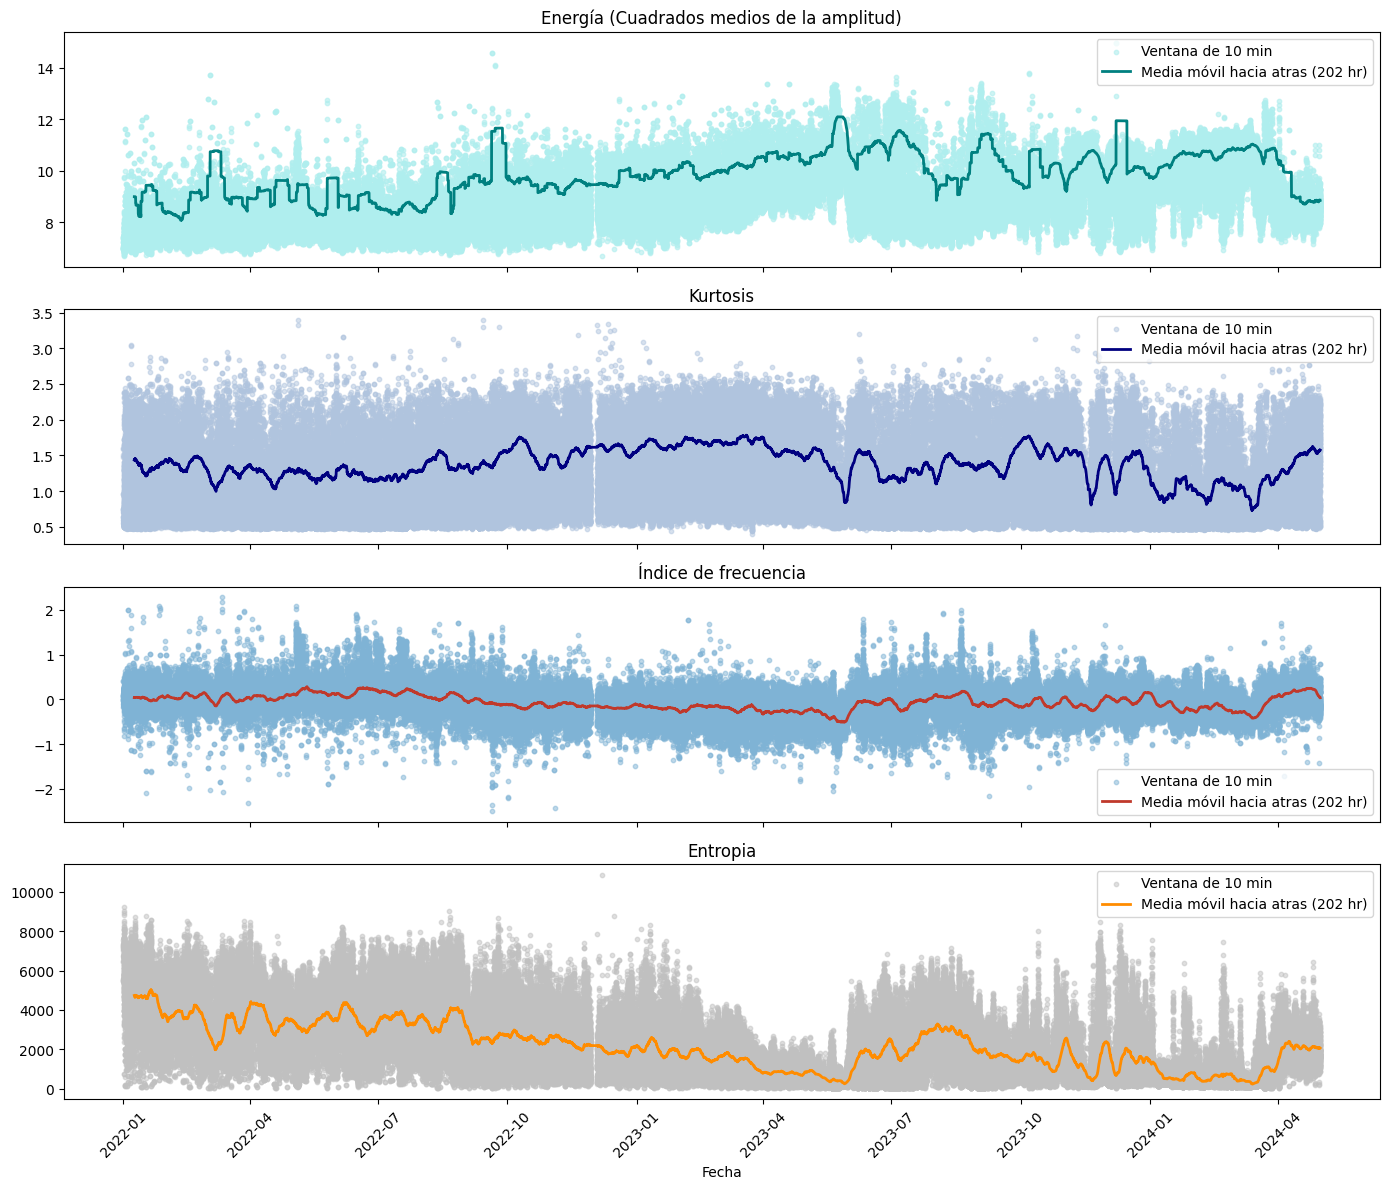

In [4]:

features_df['energy'] = np.log10(features_df['energy'])
features_df['kurtosis'] = np.log10(features_df['kurtosis'])

# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
axes[0].scatter(features_df['timestamp'], features_df['energy'], color='paleturquoise', s=10, alpha=0.6, label="Ventana de 10 min")
axes[0].plot(features_df['timestamp'], features_df['energy_movil_media'], color='teal', linewidth=2, label= f'Media móvil hacia atras ({hours} hr)')
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(loc='best')

axes[1].scatter(features_df['timestamp'], features_df['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[1].plot(features_df['timestamp'], features_df['kurtosis_mobile_mean'], color='navy', alpha = 1,linewidth=2, label= f'Media móvil hacia atras ({hours} hr)')
axes[1].set_title('Kurtosis')
axes[1].legend(loc='best')

axes[2].scatter(features_df['timestamp'], features_df['frequency_index'], color='#7FB3D5', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[2].plot(features_df['timestamp'], features_df['frequency_index_movil_media'], color='#C0392B', alpha = 1,linewidth=2, label= f'Media móvil hacia atras ({hours} hr)')
axes[2].set_title('Índice de frecuencia')
axes[2].legend(loc='best')

axes[3].scatter(features_df['timestamp'], features_df['entropy'], color='silver', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[3].plot(features_df['timestamp'], features_df['entropy_movil_media'], color='darkorange', alpha = 1,linewidth=2, label= f'Media móvil hacia atras ({hours} hr)')
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(loc='best')

plt.xticks(rotation=45)
plt.tight_layout()

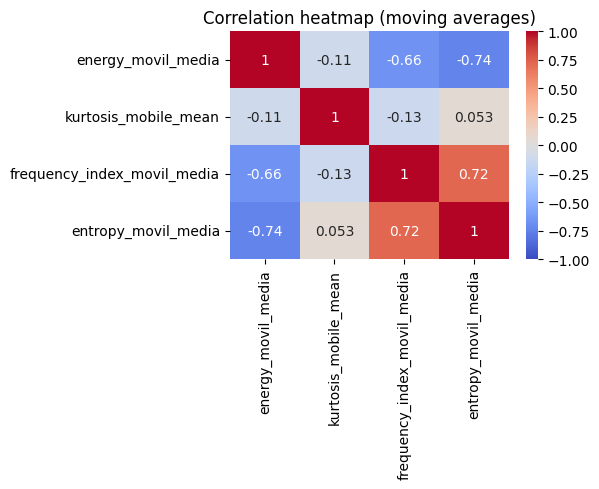

In [5]:
import seaborn as sns
# Select the four moving-average feature columns and drop missing values
corr_df = features_df[[
    'energy_movil_media',
    'kurtosis_mobile_mean',
    'frequency_index_movil_media',
    'entropy_movil_media'
]].dropna()
# Compute correlation matrix
corr = corr_df.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap (moving averages)')
plt.tight_layout()
plt.show()

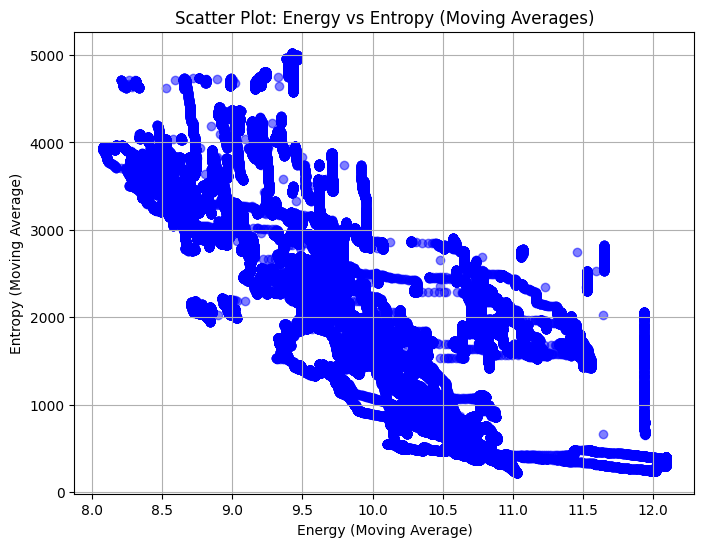

In [6]:
# Generate a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(features_df['energy_movil_media'], features_df['entropy_movil_media'], alpha=0.5, c='blue')
plt.title('Scatter Plot: Energy vs Entropy (Moving Averages)')
plt.xlabel('Energy (Moving Average)')
plt.ylabel('Entropy (Moving Average)')
plt.grid(True)
plt.show()



In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

In [21]:
clustering_data = features_df[
    [
        'energy_movil_media',
        'kurtosis_mobile_mean',
        'frequency_index_movil_media',
        'entropy_movil_media'
    ]
]

# Drop rows with missing values
clustering_data = clustering_data.dropna()

# Select columns to scale
cols_to_scale =  [
        'energy_movil_media',
        'kurtosis_mobile_mean',
        'frequency_index_movil_media',
        'entropy_movil_media'
    ]

# Crea y entrena un escalador (Robust scaler)
scaler = MinMaxScaler()
#scaler.fit(clustering_data)

scaled_data = scaler.fit_transform(clustering_data[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled = pd.DataFrame(scaled_data, columns=cols_to_scale, index=clustering_data.index)


# 4. Convert the NumPy array back to a DataFrame and maintain index/columns



#clustering_data['timestamp'] = features_df['timestamp']



# Take a random sample of 50,000 rows from the clustering data

#clustering_data = clustering_data.sample(n=50000, random_state=42)

X = df_scaled[
    [
        'energy_movil_media',
        'kurtosis_mobile_mean',
        'frequency_index_movil_media',
        'entropy_movil_media'
    ]
]



In [18]:
X

,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media
2221,0.227086,0.670207,0.692800,0.939359
2222,0.227087,0.670321,0.692624,0.939239
2223,0.227087,0.670426,0.692523,0.939082
2224,0.227088,0.670413,0.692416,0.938922
2225,0.227090,0.670525,0.692544,0.938644
...,...,...,...,...
244232,0.191743,0.801992,0.688587,0.383768
244233,0.191749,0.802245,0.688702,0.383750
244234,0.191754,0.802159,0.688924,0.383710
244235,0.191765,0.802170,0.688900,0.383625


In [10]:
clustering_data.head()

,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media
2221,8.988485,1.434037,0.037854,4734.759676
2222,8.988488,1.434158,0.037714,4734.184970
2223,8.988490,1.434268,0.037634,4733.430188
2224,8.988492,1.434254,0.037549,4732.660649
2225,8.988501,1.434373,0.037651,4731.327416


In [22]:
# Trata con differentes valores para k

xSample = X.sample(n = 50000)

inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(xSample)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(xSample, km_model.labels_))

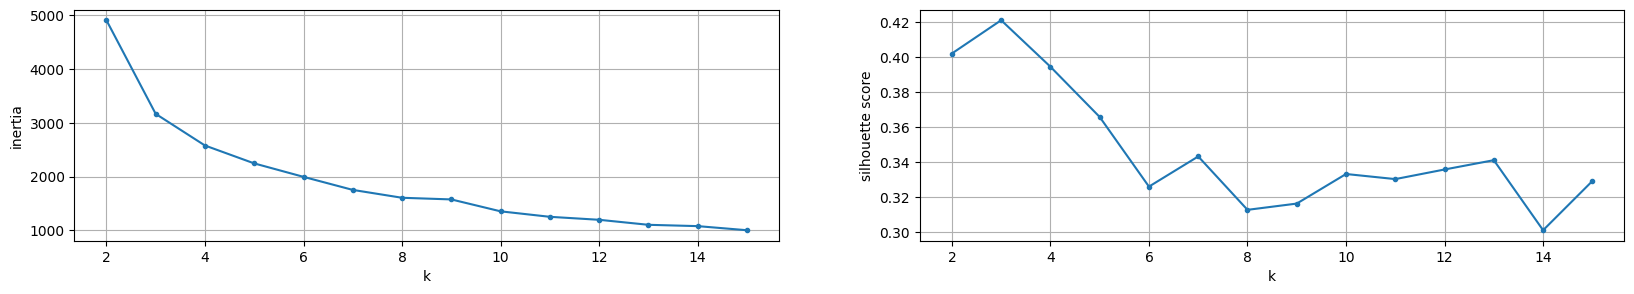

In [23]:
# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [24]:
# Repite k-means con el mejor número k
km_model = KMeans(n_clusters=3).fit(X)

clustering_data = X
clustering_data['timestamp'] = features_df['timestamp']

clustering_data['labels'] = km_model.labels_

In [28]:
clustering_data

,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media,timestamp,labels
2595,0.212631,0.660715,0.717014,0.959774,2022-01-10 01:05:00,2
2596,0.212633,0.660801,0.717028,0.959539,2022-01-10 01:10:00,2
2597,0.212636,0.660906,0.717082,0.959293,2022-01-10 01:15:00,2
2598,0.212636,0.660890,0.717097,0.959152,2022-01-10 01:20:00,2
2599,0.212637,0.660874,0.717120,0.959009,2022-01-10 01:25:00,2
...,...,...,...,...,...,...
244232,0.195193,0.815309,0.741364,0.373392,2024-04-30 23:35:00,2
244233,0.194748,0.814893,0.741184,0.373499,2024-04-30 23:40:00,2
244234,0.194551,0.814906,0.741013,0.373626,2024-04-30 23:45:00,2
244235,0.194168,0.814315,0.740917,0.373758,2024-04-30 23:50:00,2


<Figure size 1600x1200 with 0 Axes>

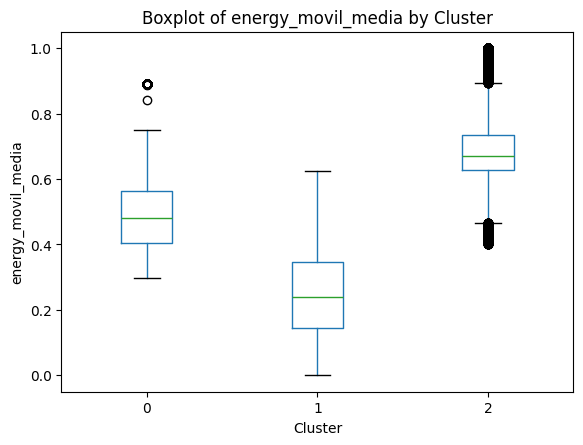

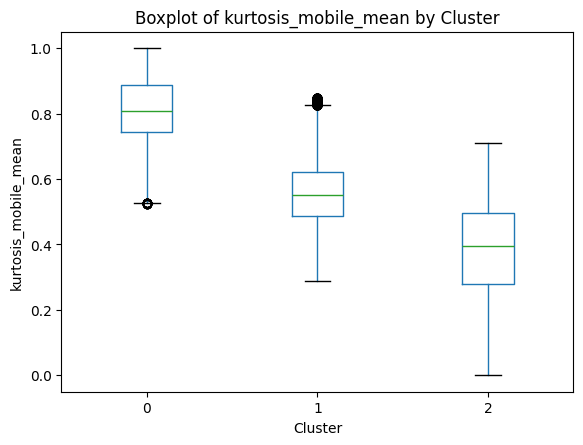

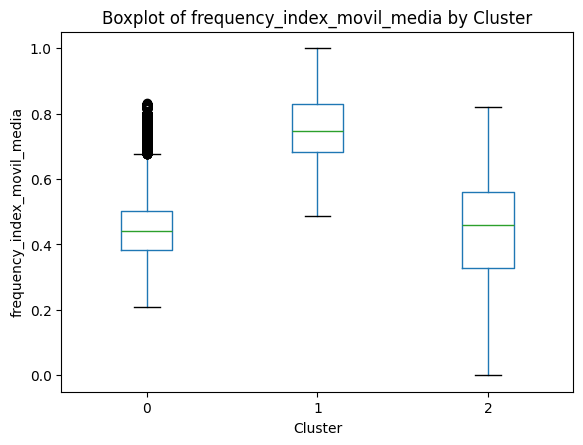

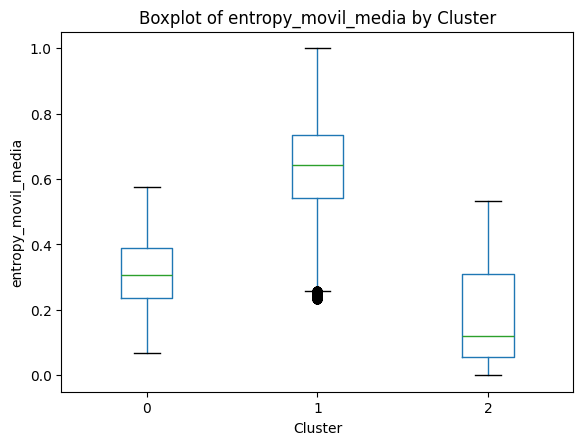

In [25]:
# Generate boxplots for each column grouped by cluster label
columns_to_plot = [
    'energy_movil_media',
    'kurtosis_mobile_mean',
    'frequency_index_movil_media',
    'entropy_movil_media'
    ]

plt.figure(figsize=(16, 12))
for column in columns_to_plot:
    clustering_data.boxplot(column=column, by='labels', grid=False)
    plt.title(f'Boxplot of {column} by Cluster')
    plt.suptitle('')  # Suppress the default title
    plt.xlabel('Cluster')
    plt.ylabel(column)

plt.show()

In [26]:
# Sort clustering data by timestamp
clustering_data = clustering_data.sort_values(by='timestamp')

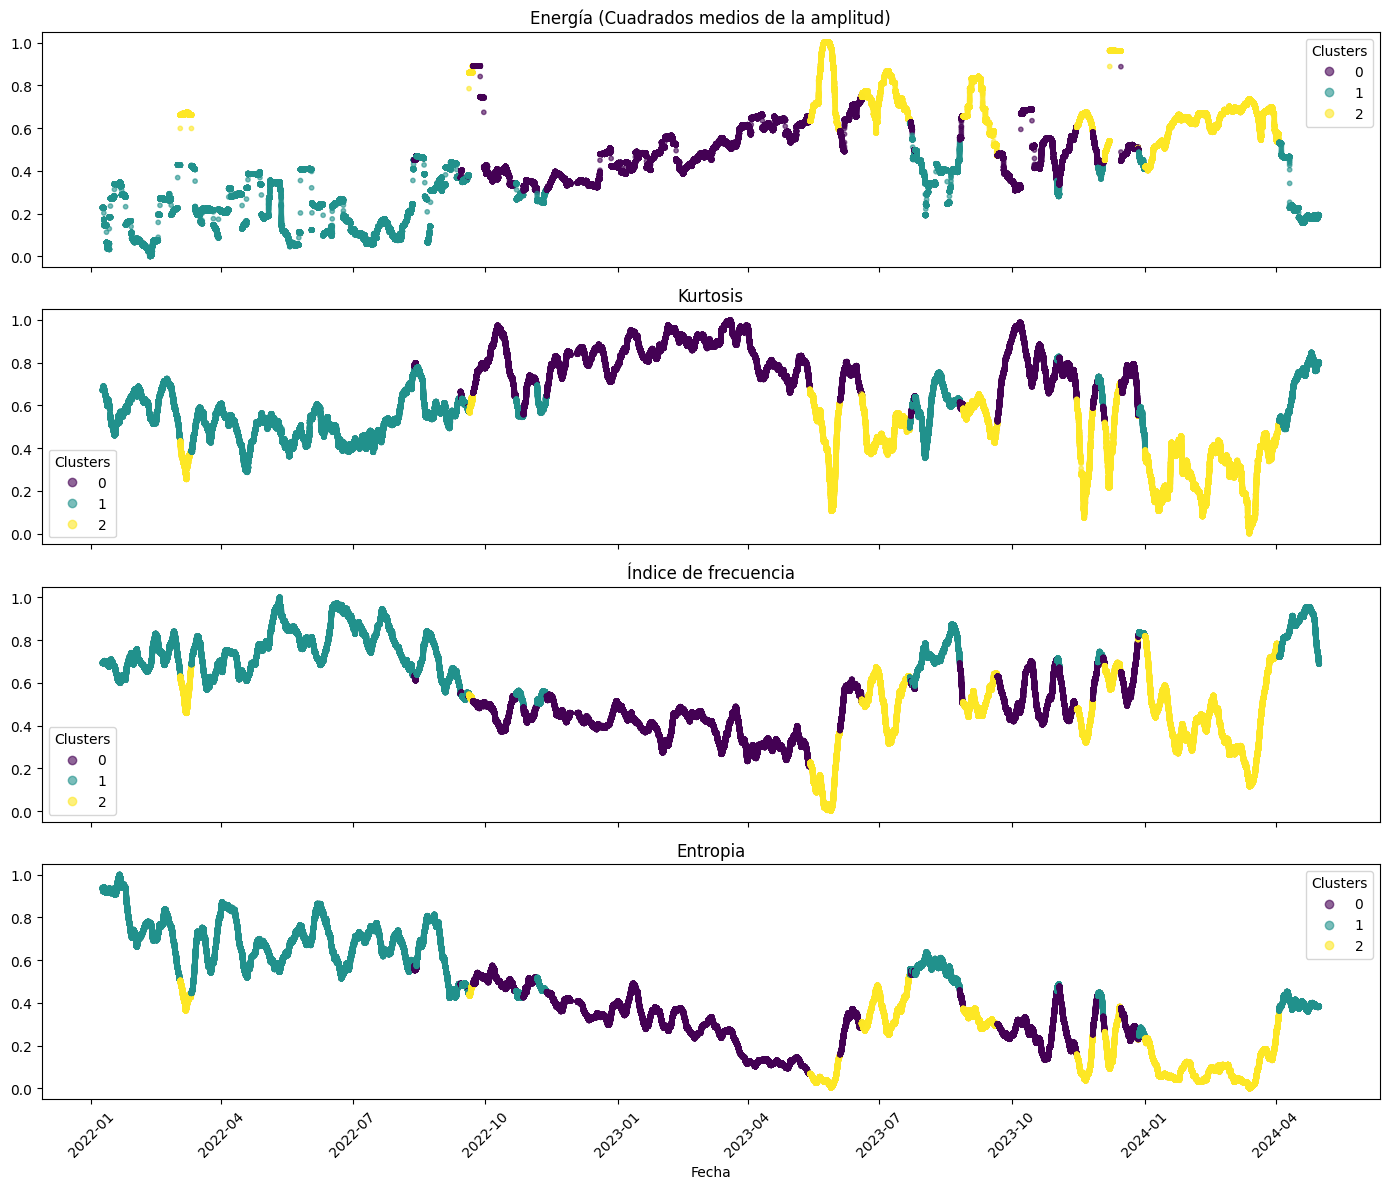

In [27]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data['timestamp'], clustering_data['energy_movil_media'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data['timestamp'], clustering_data['kurtosis_mobile_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data['timestamp'], clustering_data['frequency_index_movil_media'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data['timestamp'], clustering_data['entropy_movil_media'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()